# Training tree-cover classifiers

``random_forest`` and ``neural_network`` (multi-layer perceptron) are two
classifiers that predict tree vs non-tree pixels from temporally-aggregated
Sentinel-2 features. This notebook trains both on the same sample CSV and
compares their testing accuracy.

In [1]:
from shelterbelts.classifications.random_forest import random_forest
from shelterbelts.classifications.neural_network import train_neural_network
from shelterbelts.utils.filepaths import training_csv_sample

## Random forest

In [2]:
%%time
df_rf = random_forest(
    training_csv_sample,
    outdir='outdir',
    stub='demo_rf'
)
df_rf

Original number of samples: 2401
tree_cover
0.0            964
1.0           1437
Name: count, dtype: int64


Number of training samples: 1348
tree_cover
0.0           674
1.0           674
Name: count, dtype: int64


Number of testing samples: 580
tree_cover
0.0           290
1.0           290
Name: count, dtype: int64
Saved outdir/scaler_demo_rf.pkl
Saved: outdir/demo_rf_random_forest.pkl
Saved outdir/demo_rf_metrics.csv
   tree_class  precision    recall  f1-score  accuracy  support
0         0.0   0.846395  0.931034  0.886700  0.881034    290.0
1         1.0   0.923372  0.831034  0.874773  0.881034    290.0
CPU times: user 741 ms, sys: 8.87 ms, total: 750 ms
Wall time: 907 ms


,tree_class,precision,recall,f1-score,accuracy,support
0,0.0,0.846395,0.931034,0.886700,0.881034,290.0
1,1.0,0.923372,0.831034,0.874773,0.881034,290.0


## Neural network (MLP)

Original number of samples: 2400
tree_cover
0.0            963
1.0           1437
Name: count, dtype: int64


Number of training samples: 1348
tree_cover
0.0           674
1.0           674
Name: count, dtype: int64


Number of testing samples: 578
tree_cover
0.0           289
1.0           289
Name: count, dtype: int64
Saved outdir/scaler_demo_nn.pkl
Epoch 1/5


2026-05-06 11:45:26.602370: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


43/43 - 2s - 56ms/step - CategoricalAccuracy: 0.8383 - loss: 0.3854 - val_CategoricalAccuracy: 0.8806 - val_loss: 0.2780
Epoch 2/5
43/43 - 0s - 5ms/step - CategoricalAccuracy: 0.8769 - loss: 0.3181 - val_CategoricalAccuracy: 0.8927 - val_loss: 0.2629
Epoch 3/5
43/43 - 0s - 5ms/step - CategoricalAccuracy: 0.8850 - loss: 0.2929 - val_CategoricalAccuracy: 0.8927 - val_loss: 0.2613
Epoch 4/5
43/43 - 0s - 5ms/step - CategoricalAccuracy: 0.8858 - loss: 0.2856 - val_CategoricalAccuracy: 0.8997 - val_loss: 0.2508
Epoch 5/5
43/43 - 0s - 5ms/step - CategoricalAccuracy: 0.8932 - loss: 0.2637 - val_CategoricalAccuracy: 0.8962 - val_loss: 0.2514
Saved outdir/nn_demo_nn.keras
Saved outdir/demo_nn_training_plots.png
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Saved outdir/demo_nn_metrics.csv
   tree_class  precision    recall  f1-score  accuracy  support
0         0.0   0.876221  0.930796  0.902685  0.899654    289.0
1         1.0   0.926199  0.868512  0.896429  0.899654    289.0
   tree_class  precision 

,tree_class,precision,recall,f1-score,accuracy,support
0,0.0,0.876221,0.930796,0.902685,0.899654,289.0
1,1.0,0.926199,0.868512,0.896429,0.899654,289.0


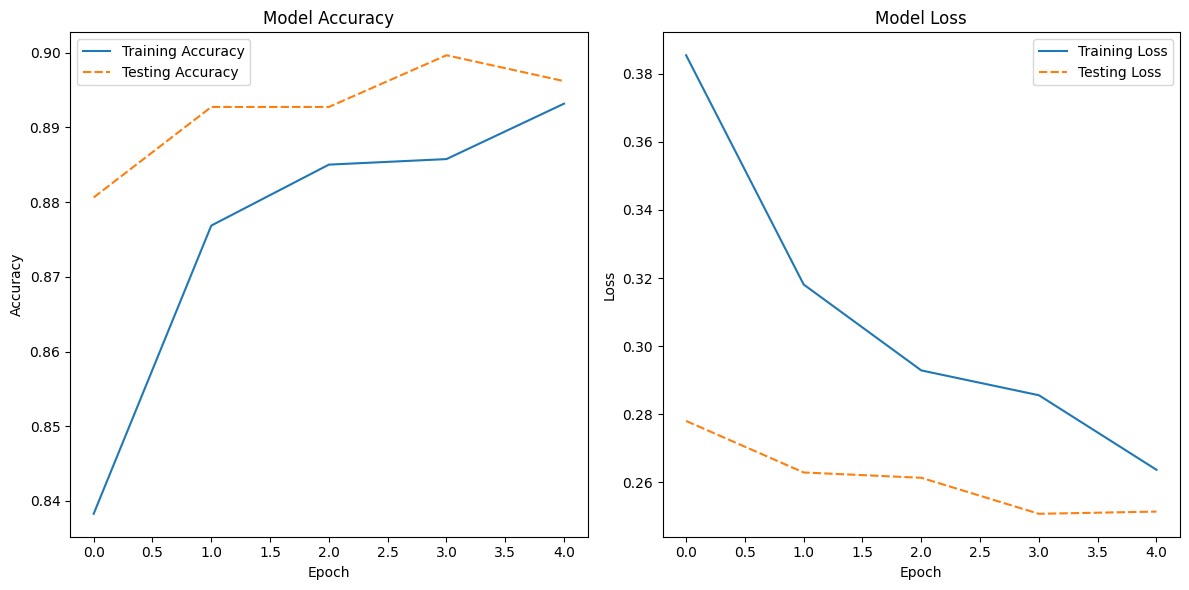

In [3]:
%%time
df_nn = train_neural_network(
    training_csv_sample,
    outdir='outdir',
    stub='demo_nn',
    epochs=5
)
df_nn

## Compare accuracy

In [4]:
import pandas as pd

df_rf['model'] = 'random_forest'
df_nn['model'] = 'neural_network'
pd.concat([df_rf, df_nn]).set_index(['model', 'tree_class'])[['precision', 'recall', 'f1-score', 'accuracy']]

precision    recall  f1-score  accuracy
model          tree_class                                         
random_forest  0.0          0.846395  0.931034  0.886700  0.881034
               1.0          0.923372  0.831034  0.874773  0.881034
neural_network 0.0          0.876221  0.930796  0.902685  0.899654
               1.0          0.926199  0.868512  0.896429  0.899654